# Setup and Dependencies


In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install timm efficientnet-pytorch
!pip install kaggle pandas scikit-learn opencv-python tqdm seaborn
!pip install torchmetrics
!pip install pydicom
!pip install --upgrade kaggle

import sys
print("✓ Dependencies installed!")
print(f"Python version: {sys.version}")

import torch
print(f"PyTorch version: {torch.__version__}")
# Use torch.version.cuda to get the CUDA toolkit version
print(f"CUDA toolkit version: {torch.version.cuda}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Looking in indexes: https://download.pytorch.org/whl/cu118
  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=3bb2142e782592d43031c397d047b6997ea361f008787cebc2e52024bb43ebc0
  Stored in directory: /root/.cache/pip/wheels/9c/3f/43/e6271c7026fe08c185da2be23c98c8e87477d3db63f41f32ad
Successfully built efficientnet-pytorch
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.5/75.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.5/160.5 kB 13.2 MB/s eta 0:00:00
  Attempting uninstall: kaggle
    Found existing installation: kaggle 1.7.4.5
    Uninstalling kaggle-1.7.4.5:
      Successfully uninstalled kaggle-1.7.4.5
✓ Dependencies installed!
Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
PyTorch

# Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Create directory for saving models
import os
os.makedirs('/content/drive/MyDrive/EyeShield/checkpoints', exist_ok=True)
os.makedirs('/content/drive/MyDrive/EyeShield/logs', exist_ok=True)

print("✓ Google Drive mounted!")
print("Save location: /content/drive/MyDrive/EyeShield/")

Mounted at /content/drive
✓ Google Drive mounted!
Save location: /content/drive/MyDrive/EyeShield/


# Setup Kaggle API

In [4]:
from google.colab import files
import json
from pathlib import Path

print("Upload your kaggle.json file...")
print("Instructions:")
print("1. Go to: https://www.kaggle.com/settings/account")
print("2. Click 'Create New API Token'")
print("3. Upload the downloaded kaggle.json file")

uploaded = files.upload()

if 'kaggle.json' in uploaded:
    kaggle_dir = Path.home() / '.kaggle'
    kaggle_dir.mkdir(exist_ok=True)

    with open(kaggle_dir / 'kaggle.json', 'w') as f:
        f.write(uploaded['kaggle.json'].decode())

    os.chmod(kaggle_dir / 'kaggle.json', 0o600)
    print("✓ Kaggle API configured!")
else:
    print("⚠ kaggle.json not found. You can continue with sample data.")

Upload your kaggle.json file...
Instructions:
1. Go to: https://www.kaggle.com/settings/account
2. Click 'Create New API Token'
3. Upload the downloaded kaggle.json file


Saving kaggle.json to kaggle.json
✓ Kaggle API configured!


# Download Dataset from Kaggle

In [6]:
import kagglehub

# Unzip if needed
import zipfile
dataset_path = kagglehub.dataset_download("ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy")

for file in os.listdir(dataset_path):
    if file.endswith('.zip'):
        with zipfile.ZipFile(os.path.join(dataset_path, file), 'r') as zip_ref:
            zip_ref.extractall(dataset_path)

print(f"✓ Dataset downloaded to: {dataset_path}")
print(f"Files: {os.listdir(dataset_path)[:10]}")


Using Colab cache for faster access to the 'eyepacs-aptos-messidor-diabetic-retinopathy' dataset.
✓ Dataset downloaded to: /kaggle/input/eyepacs-aptos-messidor-diabetic-retinopathy
Files: ['dr_unified_v2', 'augmented_resized_V2']


# Copy Training Script

In [7]:
import os
from urllib.request import urlretrieve

base_url = "https://raw.githubusercontent.com/dondondon22/EyeShield/refs/heads/main"
required_files = [
    "eyeshield_training_preprocessor.py",
    "image_processor.py",
]

print("Downloading required training files...")

for filename in required_files:
    url = f"{base_url}/{filename}"
    destination = f"/content/{filename}"

    try:
        urlretrieve(url, destination)
    except Exception as e:
        raise RuntimeError(
            f"❌ Failed to download {filename} from GitHub.\n"
            f"   URL: {url}\n"
            f"   Error: {e}"
        )

    if not os.path.exists(destination) or os.path.getsize(destination) == 0:
        raise FileNotFoundError(
            f"❌ Downloaded file is missing or empty: {destination}\n"
            f"   Check your internet connection or GitHub URL."
        )

    print(f"✓ Downloaded {filename} ({os.path.getsize(destination) / 1024:.1f} KB)")

print("\n✓ All training dependencies downloaded successfully!")

✓ Downloaded eyeshield_training_preprocessor.py (51.6 KB)
✓ Downloaded image_processor.py (15.5 KB)

✓ All training dependencies downloaded successfully!


# Prepare Dataset CSV

In [8]:
import pandas as pd
import os
from pathlib import Path

# The dataset was downloaded to `dataset_path` variable in the previous step.
# Use this variable for the root directory of the dataset.
dataset_root = kagglehub.dataset_download("ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy") # Re-define for isolated execution

# Create directory for the CSV file if it doesn't exist
os.makedirs('/content/dataset', exist_ok=True)

print(f"DEBUG: Initial dataset root: {dataset_root}")
print(f"DEBUG: Contents: {os.listdir(dataset_root)}")

# Navigate to the actual data directory (handle nested structures)
actual_data_root = dataset_root

# If there's a dr_unified_v2 directory, enter it
dr_unified_path = os.path.join(actual_data_root, 'dr_unified_v2')
if os.path.isdir(dr_unified_path):
    actual_data_root = dr_unified_path
    print(f"DEBUG: Found dr_unified_v2, moving to: {actual_data_root}")
    print(f"DEBUG: Contents: {os.listdir(actual_data_root)}")

    # Check if there's another nested dr_unified_v2
    nested_path = os.path.join(actual_data_root, 'dr_unified_v2')
    if os.path.isdir(nested_path):
        actual_data_root = nested_path
        print(f"DEBUG: Found nested dr_unified_v2, moving to: {actual_data_root}")
        print(f"DEBUG: Contents: {os.listdir(actual_data_root)}")

# Find the directory that actually contains train/val/test
# Some datasets have the splits in subdirectories
for potential_root in [actual_data_root]:
    contents = os.listdir(potential_root)
    print(f"DEBUG: Checking {potential_root}")
    print(f"DEBUG: Contents: {contents}")

    # Look for a directory that has both train and DR level directories
    for item in contents:
        item_path = os.path.join(potential_root, item)
        if os.path.isdir(item_path) and item in ['train', 'val', 'test', 'validation']:
            # Check if this contains DR levels (0-4)
            sub_contents = os.listdir(item_path)
            print(f"DEBUG: {item} contains: {sub_contents[:5]}")
            break

images = []
labels = []

# Now scan for images starting from actual_data_root
# Look for train, val, test directories at any level
def find_images_recursive(root_dir, current_path=''):
    """Recursively find images in train/val/test/[0-4] structure"""
    found_any = False
    for item in os.listdir(root_dir):
        item_path = os.path.join(root_dir, item)

        # If we find a data split directory (train, val, test, validation)
        if os.path.isdir(item_path) and item.lower() in ['train', 'val', 'test', 'validation']:
            print(f"DEBUG: Found split directory: {item_path}")
            found_any = True
            # Now look for DR levels (0-4)
            for dr_level_str in os.listdir(item_path):
                dr_path = os.path.join(item_path, dr_level_str)
                if os.path.isdir(dr_path):
                    try:
                        dr_level = int(dr_level_str)
                        # Found a DR level directory, now get images
                        for img_file in os.listdir(dr_path):
                            if img_file.lower().endswith(('.jpg', '.jpeg', '.png', '.dcm')):
                                full_path = os.path.join(dr_path, img_file)
                                rel_path = os.path.relpath(full_path, actual_data_root)
                                images.append(rel_path)
                                labels.append(dr_level)
                    except ValueError:
                        pass
        elif os.path.isdir(item_path):
            # Recursively search subdirectories
            found_any = find_images_recursive(item_path, current_path) or found_any

    return found_any

print("\n⏳ Scanning for images...")
if find_images_recursive(actual_data_root):
    print(f"✓ Found images starting from: {actual_data_root}")
else:
    print(f"⚠ No images found with standard structure")

df = pd.DataFrame({
    'image_path': images,
    'diagnosis': labels
})

df.to_csv('/content/dataset/labels.csv', index=False)

# Also save the actual_data_root so we can use it in the caching step
with open('/content/dataset/data_root.txt', 'w') as f:
    f.write(actual_data_root)

print(f"✓ Dataset CSV created!")
print(f"✓ Data root saved: {actual_data_root}")
print(f"Total images: {len(df)}")
print(f"Class distribution:\n{df['diagnosis'].value_counts().sort_index()}")
print(f"\nSample paths:")
for i, path in enumerate(df['image_path'].head(3)):
    full_path = os.path.join(actual_data_root, path)
    exists = "✓" if os.path.exists(full_path) else "✗"
    print(f"  {exists} {path}")

# VALIDATION: Check that we have data
if len(df) == 0:
    raise ValueError("❌ Dataset CSV is empty! No images were found.\n"
                    f"   Please check the dataset directory structure.\n"
                    f"   Expected: [dir]/train|val|test/[0-4]/*.jpg")
else:
    print(f"\n✓ CSV validation passed: {len(df)} images loaded successfully")


Using Colab cache for faster access to the 'eyepacs-aptos-messidor-diabetic-retinopathy' dataset.
DEBUG: Initial dataset root: /kaggle/input/eyepacs-aptos-messidor-diabetic-retinopathy
DEBUG: Contents: ['dr_unified_v2', 'augmented_resized_V2']
DEBUG: Found dr_unified_v2, moving to: /kaggle/input/eyepacs-aptos-messidor-diabetic-retinopathy/dr_unified_v2
DEBUG: Contents: ['dr_unified_v2']
DEBUG: Found nested dr_unified_v2, moving to: /kaggle/input/eyepacs-aptos-messidor-diabetic-retinopathy/dr_unified_v2/dr_unified_v2
DEBUG: Contents: ['val', 'test', 'train']
DEBUG: Checking /kaggle/input/eyepacs-aptos-messidor-diabetic-retinopathy/dr_unified_v2/dr_unified_v2
DEBUG: Contents: ['val', 'test', 'train']
DEBUG: val contains: ['2', '0', '3', '1', '4']

⏳ Scanning for images...
DEBUG: Found split directory: /kaggle/input/eyepacs-aptos-messidor-diabetic-retinopathy/dr_unified_v2/dr_unified_v2/val
DEBUG: Found split directory: /kaggle/input/eyepacs-aptos-messidor-diabetic-retinopathy/dr_unified_

# Preprocess and Cache Images (One-Time Setup)

This step preprocesses all images at once and caches them to disk. Subsequent training runs load from cache (10x faster).
Run this cell ONCE before training. Takes ~30-60 minutes depending on dataset size.

In [ ]:
# Cache will be saved to Colab ephemeral storage (/content/image_cache)
# This does NOT use Google Drive storage
# Note: Cache is cleared when session ends (run preprocessing again next session)

CACHE_DIR = '/content/image_cache'
os.makedirs(CACHE_DIR, exist_ok=True)

print(f"✓ Cache location: {CACHE_DIR}")
print(f"  Storage: Colab ephemeral (doesn't use Google Drive)")
print(f"  Available: ~80+ GB during session")
print(f"  Persists: Until session ends")
print(f"\nFirst session: Preprocess once (~1-2 hours)")
print(f"Same session: Lightning fast afterward!")

In [ ]:
import os
import numpy as np
import pickle
from pathlib import Path
from tqdm import tqdm
import shutil
import cv2
import pydicom
import pandas as pd
from sklearn.model_selection import train_test_split

# ==================== IMAGE PREPROCESSOR ====================
class ImagePreprocessor:
    """Image preprocessing for fundus images"""

    def __init__(self, target_size=(512, 512)):
        """
        Initialize preprocessor

        Args:
            target_size: Target image size (height, width)
        """
        self.target_size = target_size

    def preprocess_fundus_image(self, image_path):
        """
        Preprocesses a fundus image by resizing it to the target size.
        Supports DICOM (.dcm) and standard image formats (jpg, png, etc.)
        """
        file_ext = os.path.splitext(image_path)[1].lower()

        if file_ext == '.dcm':
            try:
                dicom = pydicom.dcmread(image_path)
                img = dicom.pixel_array

                if img.dtype != np.uint8:
                    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

                if len(img.shape) == 2:
                    img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

            except Exception as e:
                raise ValueError(f"Error reading DICOM file: {str(e)}")
        else:
            img = cv2.imread(image_path)
            if img is None:
                raise ValueError(f"Image not found or invalid path: {image_path}")

        img_resized = cv2.resize(img, self.target_size, interpolation=cv2.INTER_LANCZOS4)
        img_normalized = img_resized.astype(np.float32) / 255.0

        return img_normalized

    def assess_image_quality(self, preprocessed_img, blur_threshold=70,
                            brightness_low=30, brightness_high=220, entropy_high=7.5):
        """Assesses the quality of a preprocessed fundus image"""
        img_uint8 = (preprocessed_img * 255).astype(np.uint8)

        if len(img_uint8.shape) == 3 and img_uint8.shape[2] == 3:
            gray = cv2.cvtColor(img_uint8, cv2.COLOR_BGR2GRAY)
        else:
            gray = img_uint8 if len(img_uint8.shape) == 2 else cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)

        laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
        mean_brightness = np.mean(gray)
        hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
        hist_norm = hist / hist.sum()
        entropy = -np.sum(hist_norm * np.log2(hist_norm + 1e-10))

        quality_info = {
            'blur_var': float(laplacian_var),
            'brightness': float(mean_brightness),
            'entropy': float(entropy),
            'blur_threshold': blur_threshold,
            'brightness_low': brightness_low,
            'brightness_high': brightness_high,
            'entropy_threshold': entropy_high
        }

        if laplacian_var < blur_threshold:
            quality_result = "Rejected: Blurry or out of focus"
            quality_score = 0.3
        elif mean_brightness < brightness_low:
            quality_result = "Rejected: Too dark"
            quality_score = 0.2
        elif mean_brightness > brightness_high:
            quality_result = "Rejected: Too bright"
            quality_score = 0.2
        elif entropy > entropy_high:
            quality_result = "Rejected: Artifacts or obstructions"
            quality_score = 0.4
        else:
            quality_result = "Gradable"
            quality_score = 0.9

        return quality_score, quality_result, quality_info

    def preprocess(self, image_path, assess_quality=True):
        """Complete preprocessing pipeline"""
        try:
            image = self.preprocess_fundus_image(image_path)

            if assess_quality:
                quality_score, quality_result, quality_info = self.assess_image_quality(image)
            else:
                quality_score = 1.0
                quality_result = "Not assessed"
                quality_info = {}

            return image, quality_score, quality_info
        except Exception as e:
            print(f"Error preprocessing {image_path}: {e}")
            return None, 0.0, {}


# ==================== IMAGE CACHE MANAGER ====================
class ImageCacheManager:
    """Manage image preprocessing and caching"""

    def __init__(self, cache_dir='/content/image_cache', preprocessor=None):
        self.cache_dir = cache_dir
        self.preprocessor = preprocessor
        os.makedirs(cache_dir, exist_ok=True)
        self.metadata_file = os.path.join(cache_dir, 'metadata.pkl')

    def get_cache_path(self, image_filename):
        """Get cache file path for an image"""
        # Remove any path separators and create safe filename
        safe_filename = image_filename.replace('/', '__').replace('\\', '__')
        return os.path.join(self.cache_dir, f"{safe_filename}.npy")

    def preprocess_and_cache(self, df, dataset_root, force_reprocess=False):
        """
        Preprocess all images and cache them as uint8 (4x smaller than float32).
        Images are stored in [0, 255] uint8 and converted back to [0.0, 1.0] float32 on load.

        Args:
            df: DataFrame with 'image_path' column
            dataset_root: Root directory containing images
            force_reprocess: If True, reprocess even if cached
        """
        print(f"Preprocessing {len(df)} images to cache...")
        print(f"Cache location: {self.cache_dir}")
        print(f"Dataset root: {dataset_root}")
        print(f"Storage format: uint8 (4x smaller than float32)\n")

        cached_count = 0
        new_count = 0
        failed_images = []

        cache_metadata = {}

        pbar = tqdm(total=len(df), desc='Caching images')

        for idx, row in df.iterrows():
            img_path = os.path.join(dataset_root, row['image_path'])
            cache_path = self.get_cache_path(row['image_path'])

            if os.path.exists(cache_path) and not force_reprocess:
                cached_count += 1
                cache_metadata[row['image_path']] = 'cached'
                pbar.update(1)
                continue

            try:
                preprocessed_img, quality_score, quality_info = self.preprocessor.preprocess(
                    img_path, assess_quality=False
                )

                if preprocessed_img is None:
                    failed_images.append((row['image_path'], 'Preprocessing returned None'))
                    pbar.update(1)
                    continue

                # Save as uint8 [0, 255] — 4x smaller than float32 [0.0, 1.0]
                # load_cached_image converts back to float32 on load
                np.save(cache_path, (preprocessed_img * 255).astype(np.uint8))
                new_count += 1
                cache_metadata[row['image_path']] = 'new'

            except Exception as e:
                failed_images.append((row['image_path'], str(e)))
                cache_metadata[row['image_path']] = 'failed'

            pbar.update(1)

        pbar.close()

        with open(self.metadata_file, 'wb') as f:
            pickle.dump(cache_metadata, f)

        print(f"\n{'='*80}")
        print(f"CACHING COMPLETE")
        print(f"{'='*80}")
        print(f"Total images: {len(df)}")
        print(f"  ✓ Already cached: {cached_count}")
        print(f"  ✓ Newly cached: {new_count}")
        print(f"  ✗ Failed: {len(failed_images)}")
        print(f"\nCache size: {self._get_cache_size_gb():.2f} GB")
        print(f"{'='*80}\n")

        if failed_images:
            print("Failed images:")
            for img_path, error in failed_images[:10]:
                print(f"  - {img_path}: {error}")
            if len(failed_images) > 10:
                print(f"  ... and {len(failed_images) - 10} more")

        return len(failed_images) == 0

    def load_cached_image(self, image_filename):
        """Load preprocessed image from cache, converting uint8 back to float32"""
        cache_path = self.get_cache_path(image_filename)
        if not os.path.exists(cache_path):
            raise FileNotFoundError(f"Cached image not found: {cache_path}")
        img = np.load(cache_path)
        # Convert uint8 [0, 255] back to float32 [0.0, 1.0]
        if img.dtype == np.uint8:
            return img.astype(np.float32) / 255.0
        return img.astype(np.float32)

    def clear_cache(self):
        """Clear all cached images"""
        if os.path.exists(self.cache_dir):
            shutil.rmtree(self.cache_dir)
            os.makedirs(self.cache_dir)
            print(f"✓ Cache cleared: {self.cache_dir}")

    def _get_cache_size_gb(self):
        """Get total cache size in GB"""
        total_size = 0
        for file in os.listdir(self.cache_dir):
            file_path = os.path.join(self.cache_dir, file)
            if os.path.isfile(file_path):
                total_size += os.path.getsize(file_path)
        return total_size / (1024**3)


# STEP 1: Clear old cache if it exists (to remove files with incorrect paths)
print("⏳ Clearing old cache with incorrect paths...")
cache_dir = '/content/image_cache'
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print("✓ Old cache cleared")
os.makedirs(cache_dir, exist_ok=True)

# Initialize image preprocessor
print("✓ Initializing ImagePreprocessor...")
preprocessor = ImagePreprocessor(target_size=(512, 512))
print(f"  - Target size: (512, 512)")

# Initialize cache manager with preprocessor
print("✓ Initializing ImageCacheManager...")
cache_manager = ImageCacheManager(
    cache_dir='/content/image_cache',
    preprocessor=preprocessor
)
print(f"  - Cache directory: /content/image_cache")

# Load the dataset CSV and cache all images
print("\n⏳ Loading dataset from CSV...")
csv_path = '/content/dataset/labels.csv'
df = pd.read_csv(csv_path)
print(f"✓ Loaded {len(df)} images from {csv_path}")

# Load the data root that was saved during CSV creation
data_root_file = '/content/dataset/data_root.txt'
if os.path.exists(data_root_file):
    with open(data_root_file, 'r') as f:
        dataset_root = f.read().strip()
    print(f"✓ Using saved data root: {dataset_root}")
else:
    # Fallback if data_root.txt doesn't exist
    import kagglehub
    dataset_root = kagglehub.dataset_download("ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy")
    print(f"⚠ data_root.txt not found, using fresh download: {dataset_root}")

# Verify the actual data paths will be found
print("\n⏳ Verifying image paths...")
sample_path = os.path.join(dataset_root, df.iloc[0]['image_path'])
if os.path.exists(sample_path):
    print(f"✓ Sample image found: {sample_path}")
else:
    print(f"✗ Warning: Sample image not found at {sample_path}")
    print(f"  CSV image_path: {df.iloc[0]['image_path']}")
    print(f"  Data root: {dataset_root}")
    print(f"  Tried path: {sample_path}")
    # Show what's actually in the directory
    print(f"  Contents of data root: {os.listdir(dataset_root)[:5]}")

# Prepare all images for caching
print("\n⏳ Starting image caching operation...")
print("This is a one-time operation; subsequent runs will skip already-cached images\n")
cache_manager.preprocess_and_cache(df, dataset_root, force_reprocess=False)

print("✓ Images cached! Training will now load from cache (10x faster).")
print("  To recache (if you change preprocessing), call:")
print("  cache_manager.preprocess_and_cache(df, dataset_root, force_reprocess=True)")


# Important: Cache is Ephemeral in Colab

⚠️ **Important:** The cache will be cleared when your Colab session ends.

**Workflow:**
- First run in session: Preprocess all images (~30-60 min) → stored in `/content/image_cache`
- Train immediately after: Use cached images (6 min/epoch) ✓
- Next Colab session: Must preprocess again (cache was deleted)

**To minimize re-preprocessing:**
- Keep the same session running during all your training epochs
- Don't restart the kernel
- If session times out, just run preprocessing again

# Modify Config and Run Training

In [9]:
# Read the training script
with open('/content/eyeshield_training_preprocessor.py', 'r') as f:
    training_code = f.read()

# Modify paths in the Config class (if needed)
modified_code = training_code.replace(
    "CHECKPOINT_DIR = './checkpoints'",
    "CHECKPOINT_DIR = '/content/drive/MyDrive/EyeShield/checkpoints'"
)

modified_code = modified_code.replace(
    "LOG_DIR = './logs'",
    "LOG_DIR = '/content/drive/MyDrive/EyeShield/logs'"
)

# Save modified script
with open('/content/eyeshield_training_preprocessor_modified.py', 'w') as f:
    f.write(modified_code)

print("✓ Configuration updated!")
print("Ready to start training...")

✓ Configuration updated!
Ready to start training...


# Backup

In [ ]:

# Setup Auto-Backup on Colab Interruption
import shutil
import signal
import atexit
from datetime import datetime as dt

backup_executed = False

def backup_all_files():
    """Backup CSV and training artifacts to Google Drive"""
    global backup_executed
    if backup_executed:
        return

    backup_executed = True
    print("\n" + "="*80)
    print("EXECUTING BACKUP TO GOOGLE DRIVE")
    print("="*80)

    try:
        # Backup CSV to Drive
        csv_source = '/content/dataset/labels.csv'
        csv_dest = '/content/drive/MyDrive/EyeShield/labels_backup.csv'

        if os.path.exists(csv_source):
            shutil.copy2(csv_source, csv_dest)
            print(f"✓ Backed up CSV: {csv_dest}")
        else:
            print(f"⚠ CSV not found at {csv_source}")

        # Backup logs directory
        logs_source = '/content/logs'
        logs_dest = '/content/drive/MyDrive/EyeShield/logs_backup'

        if os.path.exists(logs_source):
            if os.path.exists(logs_dest):
                shutil.rmtree(logs_dest)
            shutil.copytree(logs_source, logs_dest)
            print(f"✓ Backed up logs: {logs_dest}")

        # Backup modified training script
        script_source = '/content/eyeshield_training_preprocessor_modified.py'
        script_dest = '/content/drive/MyDrive/EyeShield/training_script_backup.py'

        if os.path.exists(script_source):
            shutil.copy2(script_source, script_dest)
            print(f"✓ Backed up training script: {script_dest}")

        backup_time = dt.now().strftime('%Y-%m-%d %H:%M:%S')
        print(f"Backup timestamp: {backup_time}")
        print("="*80 + "\n")

    except Exception as e:
        print(f"❌ Backup error: {e}")
        import traceback
        traceback.print_exc()

def signal_handler(sig, frame):
    """Handle interruption signal"""
    print("\n⚠ Colab interruption detected! Running backup...")
    backup_all_files()
    raise KeyboardInterrupt

# Register backup to run on exit
atexit.register(backup_all_files)

# Register signal handlers for interruption
signal.signal(signal.SIGTERM, signal_handler)
signal.signal(signal.SIGINT, signal_handler)

print("✓ Auto-backup enabled on Colab stop/interruption")



#  DEbug Training

In [ ]:
# Debug: Verify all dependencies and paths exist

import os
import sys

print("=" * 80)
print("PRE-TRAINING CHECKS")
print("=" * 80)

# Check Python version
print(f"\n1. Python Version: {sys.version}")

# Check required packages
required_packages = ['torch', 'pandas', 'cv2', 'PIL', 'pydicom', 'sklearn']
print(f"\n2. Checking packages:")
for pkg in required_packages:
    try:
        __import__(pkg)
        print(f"   ✓ {pkg} available")
    except ImportError:
        print(f"   ✗ {pkg} NOT AVAILABLE")

# Check file paths
print(f"\n3. Checking file paths:")
files_to_check = [
    '/content/eyeshield_training_preprocessor_modified.py',
    '/content/dataset/labels.csv',
    '/content/drive/MyDrive/EyeShield/checkpoints',
    '/content/drive/MyDrive/EyeShield/logs'
]

for path in files_to_check:
    exists = os.path.exists(path)
    status = "✓" if exists else "✗"
    print(f"   {status} {path}")

# Check dataset CSV
try:
    import pandas as pd
    df = pd.read_csv('/content/dataset/labels.csv')
    print(f"\n4. Dataset CSV:")
    print(f"   ✓ Loaded {len(df)} records")
    print(f"   Columns: {list(df.columns)}")
    print(f"   Class distribution:\n{df['diagnosis'].value_counts().sort_index()}")
except Exception as e:
    print(f"\n4. Dataset CSV: ✗ Error - {e}")

print("\n" + "=" * 80)


In [ ]:

# Manual Backup (Run Anytime)
backup_all_files()
print("Manual backup completed. You can run this cell anytime to backup current progress.")


# TRAIN

PRE-TRAINING VALIDATION
✓ CSV exists with 92501 images
✓ Training script ready
✓ image_processor module ready
✓ Backup function available
✓ All prerequisites satisfied. Starting training...

/content
✓ image_processor compatibility patch applied
Loading training script...
Device: cuda
CUDA Available: True
GPU: NVIDIA L4

EyeShield: DR Classification Model Training (Sprint 3)
Using Your Image Preprocessor (No CLAHE)
Configuration:
  - Num Classes: 5
  - Target Preprocessing Size: (512, 512)
  - Input Size: (512, 512)
  - Batch Size: 32
  - Num Epochs: 100
  - Learning Rate: 0.0001
  - EDL KL Weight: 0.1
  - Quality Check: False

Initializing image preprocessor...
✓ Image preprocessor initialized
  - Target size: (512, 512)
  - Quality assessment: Disabled

Loading dataset from CSV...
⚠️  Limiting dataset from 92501 → 60000 images
✓ Using 59997 images for training
Resolving dataset root...
✓ Dataset root resolved: /root/.cache/kagglehub/datasets/ascanipek/eyepacs-aptos-messidor-diabetic-

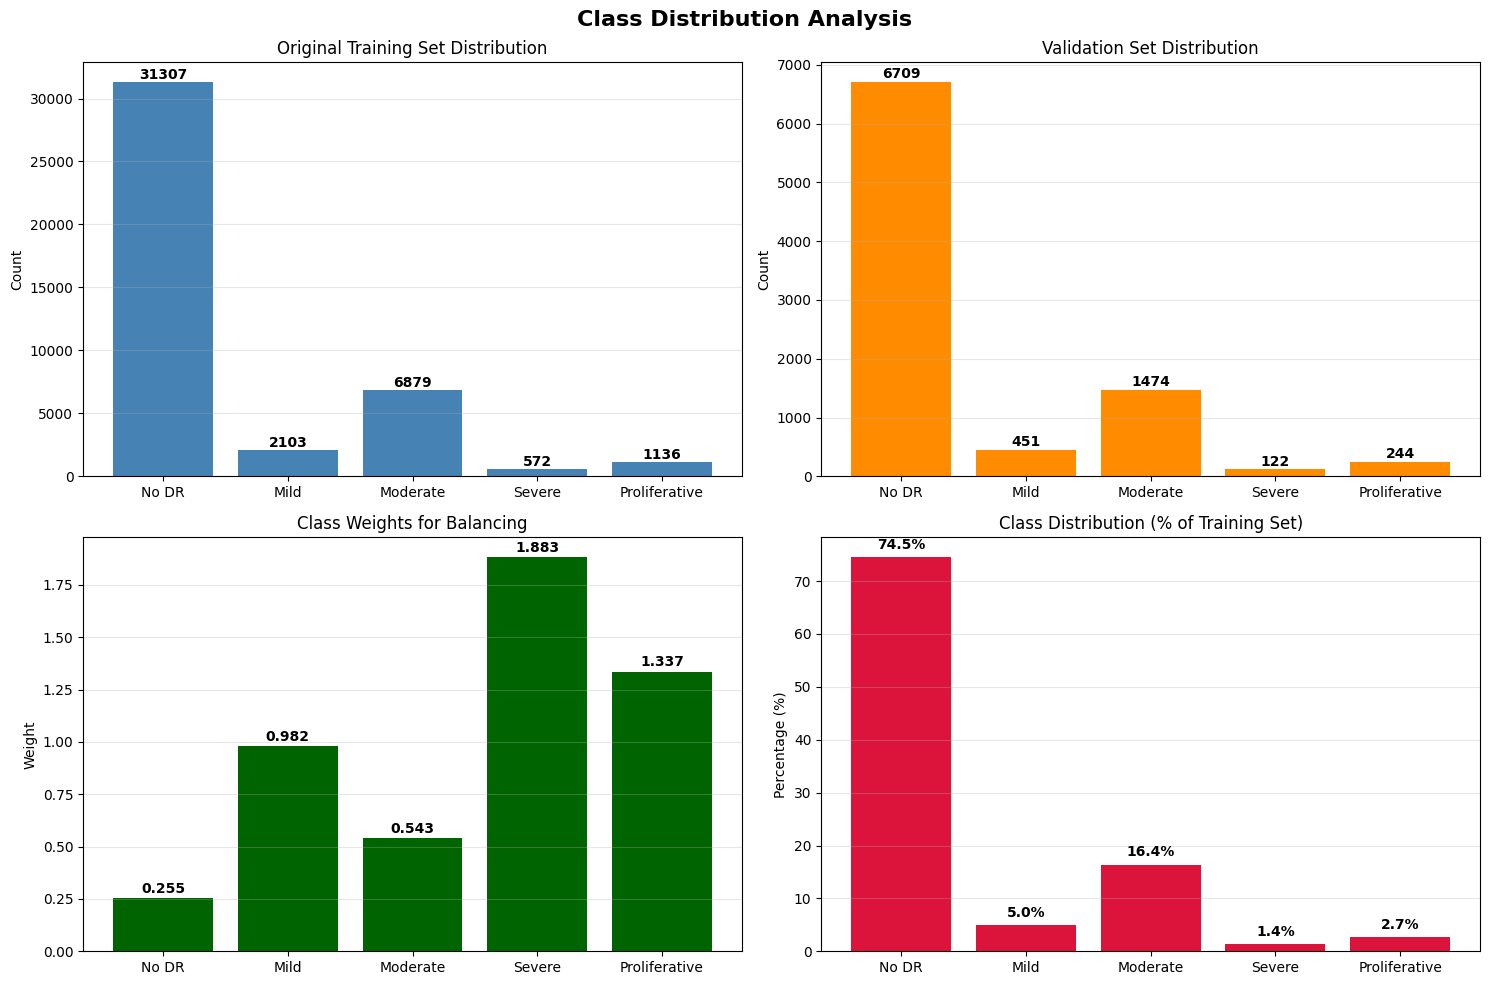


CLASS DISTRIBUTION STATISTICS

Training Set (41997 total):
  No DR          : 31307 samples ( 74.5%) | Weight: 0.2546
  Mild           :  2103 samples (  5.0%) | Weight: 0.9823
  Moderate       :  6879 samples ( 16.4%) | Weight: 0.5431
  Severe         :   572 samples (  1.4%) | Weight: 1.8835
  Proliferative  :  1136 samples (  2.7%) | Weight: 1.3365

Validation Set (9000 total):
  No DR          :  6709 samples ( 74.5%)
  Mild           :   451 samples (  5.0%)
  Moderate       :  1474 samples ( 16.4%)
  Severe         :   122 samples (  1.4%)
  Proliferative  :   244 samples (  2.7%)

Test Set (9000 total):
  No DR          :  6709 samples ( 74.5%)
  Mild           :   451 samples (  5.0%)
  Moderate       :  1474 samples ( 16.4%)
  Severe         :   122 samples (  1.4%)
  Proliferative  :   244 samples (  2.7%)

Imbalance Ratio (max/min): 54.73


PREPROCESSING AND CACHING IMAGES
This is a one-time operation. Subsequent runs will skip already-cached images.

Preprocessing 59997 im

Caching images: 100%|██████████| 59997/59997 [00:03<00:00, 17703.50img/s]



CACHING COMPLETE
Total images:      59997
  ✓ Already cached: 59997
  ✓ Newly cached:   0
  ✗ Failed:         0

Cache size:        67.76 GB

✓ Train: All samples have cached files
✓ Val: All samples have cached files
Recalculating class weights after cache validation...
✓ Images cached! Training will now load from cache (10x faster).

Loading datasets from cache...
✓ Datasets loaded:
  - Train: 41997 images (cached)
  - Val: 9000 images (cached)
  - Expected per-epoch time: ~6 minutes (down from 58 minutes)

Initializing model...
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 189MB/s]


Total Parameters: 11,550,765
Trainable Parameters: 11,550,765


Starting Training: EfficientNet-B3 + EDL for DR Classification
Using Your Image Preprocessor



...


Epoch 50/100
Train Loss: 0.4450 | Train Acc: 0.8800 | Train Macro F1: 0.7315
Val Loss: 0.4632 | Val Acc: 0.8484 | Val Macro F1: 0.5703 | ECE: 0.5095
Uncertainty — Vacuity: 0.6611 | Aleatoric: 1.1837 | Epistemic: 0.2214
Checkpoint saved: /content/drive/MyDrive/EyeShield/checkpoints/checkpoint_epoch_50_f1_0.5703.pt


Validation: 100%|██████████| 282/282 [01:17<00:00,  3.63it/s]



Epoch 51/100
Train Loss: 0.4445 | Train Acc: 0.8822 | Train Macro F1: 0.7397
Val Loss: 0.4641 | Val Acc: 0.8457 | Val Macro F1: 0.5716 | ECE: 0.5038
Uncertainty — Vacuity: 0.6580 | Aleatoric: 1.1813 | Epistemic: 0.2204


Validation: 100%|██████████| 282/282 [01:17<00:00,  3.63it/s]



Epoch 52/100
Train Loss: 0.4445 | Train Acc: 0.8827 | Train Macro F1: 0.7354
Val Loss: 0.4636 | Val Acc: 0.8494 | Val Macro F1: 0.5721 | ECE: 0.4989
Uncertainty — Vacuity: 0.6495 | Aleatoric: 1.1761 | Epistemic: 0.2177

Early stopping at epoch 52 (val macro F1 did not improve)

Training Complete!
Training history plot saved to /content/drive/MyDrive/EyeShield/logs


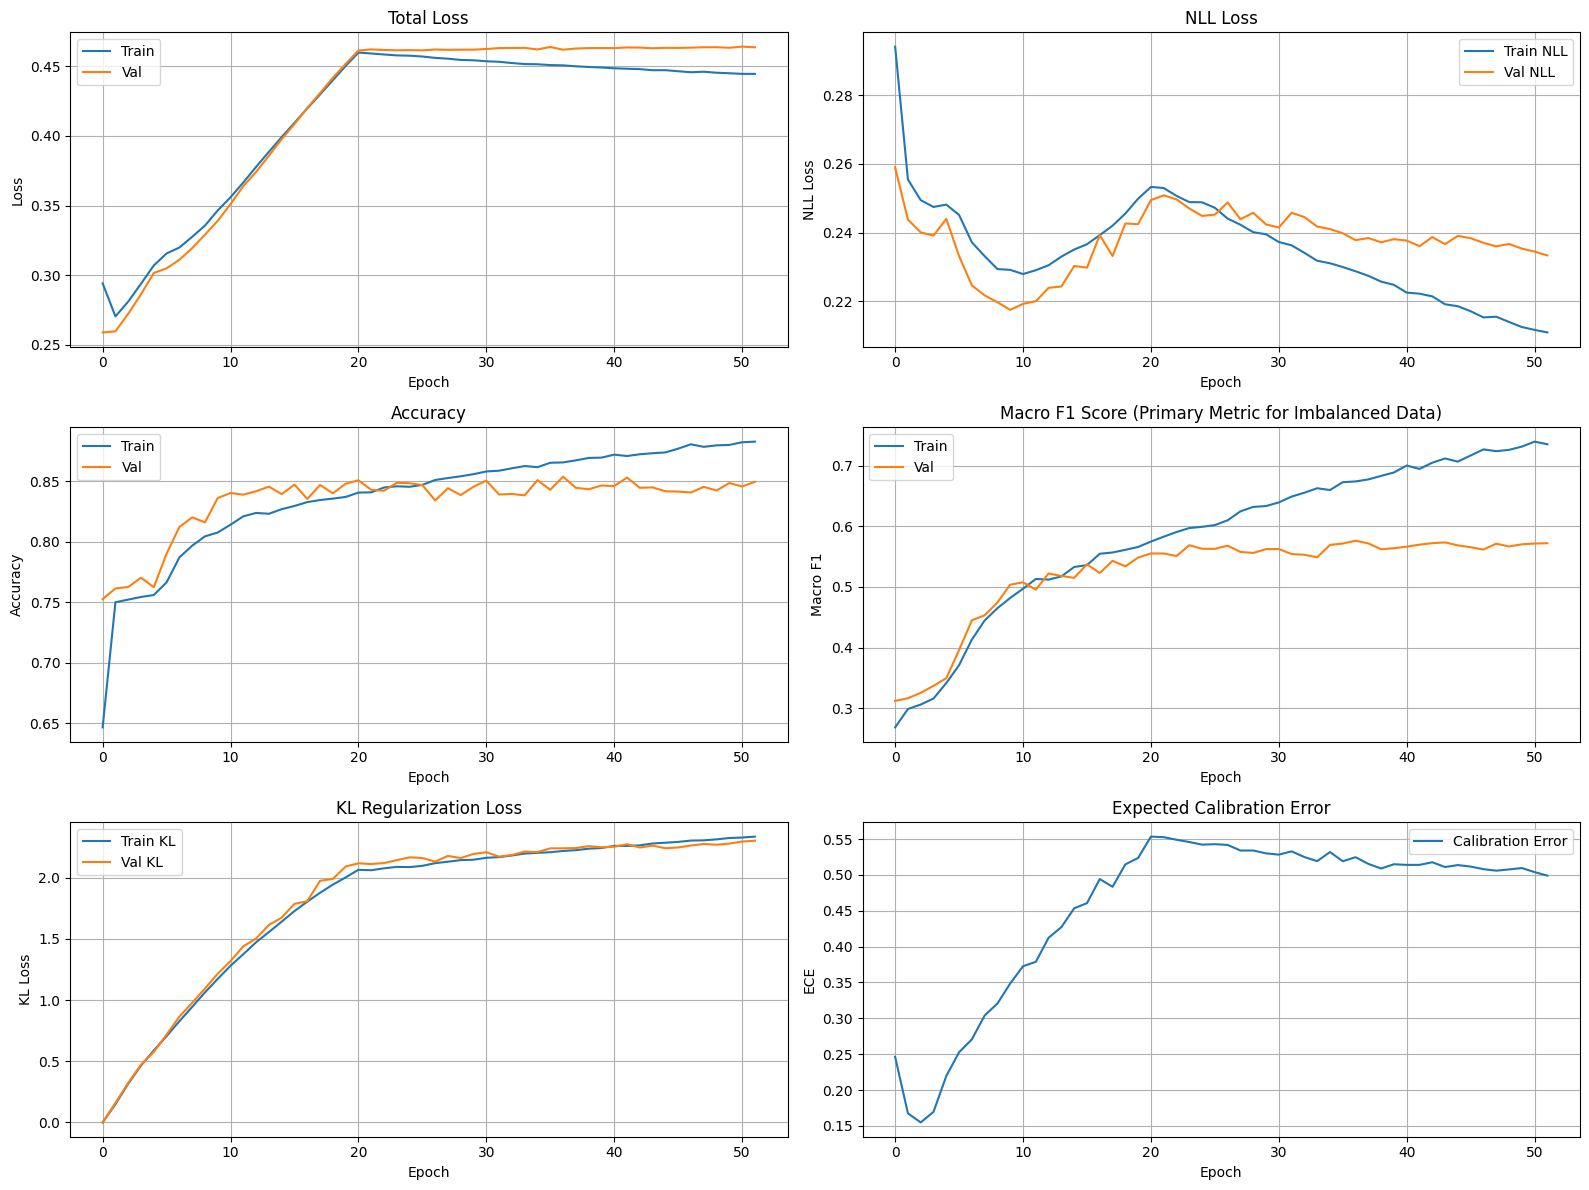


Final model saved to /content/drive/MyDrive/EyeShield/checkpoints/final_model.pth

✓ Training completed!

⏳ Running final backup...

EXECUTING BACKUP TO GOOGLE DRIVE
✓ Backed up CSV: /content/drive/MyDrive/EyeShield/labels_backup.csv
✓ Backed up training script: /content/drive/MyDrive/EyeShield/training_script_backup.py
Backup timestamp: 2026-03-15 14:15:29

✓ All files backed up to Google Drive


In [ ]:
# Validate prerequisites before training
import os

print("="*80)
print("PRE-TRAINING VALIDATION")
print("="*80)

# Check 1: CSV exists and has data
csv_path = '/content/dataset/labels.csv'
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"❌ Dataset CSV not found: {csv_path}\n"
                           f"   Please run the 'Prepare Dataset CSV' cell first")

import pandas as pd
df = pd.read_csv(csv_path)
if len(df) == 0:
    raise ValueError(f"❌ Dataset CSV is empty: {csv_path}\n"
                    f"   The CSV was created but contains no images.")

print(f"✓ CSV exists with {len(df)} images")

# Check 2: Training script exists
script_path = '/content/eyeshield_training_preprocessor_modified.py'
if not os.path.exists(script_path):
    raise FileNotFoundError(f"❌ Training script not found: {script_path}\n"
                           f"   Please run the 'Modify Config and Run Training' cell first")
print(f"✓ Training script ready")

# Check 2b: image_processor module exists (required by training script)
image_processor_path = '/content/image_processor.py'
if not os.path.exists(image_processor_path) or os.path.getsize(image_processor_path) == 0:
    print("⚠ image_processor.py not found. Attempting to download...")
    from urllib.request import urlretrieve

    image_processor_url = "https://raw.githubusercontent.com/dondondon22/EyeShield/refs/heads/main/image_processor.py"
    try:
        urlretrieve(image_processor_url, image_processor_path)
    except Exception as e:
        raise FileNotFoundError(
            f"❌ Required module missing: {image_processor_path}\n"
            f"   Auto-download failed: {e}\n"
            f"   Please rerun the 'Copy Training Script' cell."
        )

if not os.path.exists(image_processor_path) or os.path.getsize(image_processor_path) == 0:
    raise FileNotFoundError(
        f"❌ Required module is still missing or empty: {image_processor_path}\n"
        f"   Please rerun the 'Copy Training Script' cell."
    )

print("✓ image_processor module ready")

# Check 3: Backup function exists
try:
    backup_all_files  # Test if function is defined
    print("✓ Backup function available")
except NameError:
    raise NameError("❌ Backup function not defined. Please run 'Backup' cell first")

print("="*80)
print("✓ All prerequisites satisfied. Starting training...\n")

# Execute the full training pipeline
%cd /content

import sys
if '/content' not in sys.path:
    sys.path.insert(0, '/content')

# Compatibility patch for older image_processor.py versions downloaded from GitHub
import importlib.util
import numpy as np

def patch_image_processor_module(module_path='/content/image_processor.py'):
    """Patch ImageCacheManager methods at runtime for backward compatibility."""
    if not os.path.exists(module_path):
        raise FileNotFoundError(f"image_processor.py not found at {module_path}")

    spec = importlib.util.spec_from_file_location('image_processor', module_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)

    def _safe_get_cache_path(self, image_filename):
        safe_filename = str(image_filename).replace('/', '__').replace('\\', '__')
        return os.path.join(self.cache_dir, f"{safe_filename}.npy")

    def _legacy_get_cache_path(self, image_filename):
        return os.path.join(self.cache_dir, f"{image_filename}.npy")

    def _cache_exists(self, image_filename):
        return os.path.exists(_safe_get_cache_path(self, image_filename)) or os.path.exists(
            _legacy_get_cache_path(self, image_filename)
        )

    def _load_cached_image(self, image_filename):
        new_path = _safe_get_cache_path(self, image_filename)
        legacy_path = _legacy_get_cache_path(self, image_filename)

        if os.path.exists(new_path):
            img = np.load(new_path)
        elif os.path.exists(legacy_path):
            img = np.load(legacy_path)
        else:
            raise FileNotFoundError(
                f"Cached image not found in either format:\n"
                f"  - New: {new_path}\n"
                f"  - Legacy: {legacy_path}"
            )

        if img.dtype == np.uint8:
            return img.astype(np.float32) / 255.0
        return img.astype(np.float32)

    def _get_cache_size_gb(self):
        total_size = 0
        if os.path.exists(self.cache_dir):
            for root, _, files in os.walk(self.cache_dir):
                for file in files:
                    if file.endswith('.npy'):
                        file_path = os.path.join(root, file)
                        if os.path.isfile(file_path):
                            total_size += os.path.getsize(file_path)
        return total_size / (1024**3)

    # Patch class methods (safe even if already present)
    module.ImageCacheManager.get_cache_path = _safe_get_cache_path
    module.ImageCacheManager._get_legacy_cache_path = _legacy_get_cache_path
    module.ImageCacheManager.cache_exists = _cache_exists
    module.ImageCacheManager.load_cached_image = _load_cached_image
    module.ImageCacheManager._get_cache_size_gb = _get_cache_size_gb

    # Ensure training script import uses this patched module
    sys.modules['image_processor'] = module

patch_image_processor_module(image_processor_path)
print("✓ image_processor compatibility patch applied")

# Import all training components
print("Loading training script...")
try:
    # Read the modified training script
    with open('/content/eyeshield_training_preprocessor_modified.py', 'r') as f:
        training_script = f.read()

    # Create a namespace with all required modules
    import torch
    import numpy as np
    import matplotlib
    import matplotlib.pyplot as plt
    import seaborn
    from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import train_test_split
    import cv2
    from PIL import Image
    import pydicom
    from torch.utils.data import WeightedRandomSampler
    import kagglehub

    exec_namespace = {
        '__name__': '__main__',
        '__file__': '/content/eyeshield_training_preprocessor_modified.py',
        'torch': torch,
        'np': np,
        'plt': plt,
        'pd': pd,
        'cv2': cv2,
        'Image': Image,
        'pydicom': pydicom,
        'WeightedRandomSampler': WeightedRandomSampler,
        'train_test_split': train_test_split,
        'confusion_matrix': confusion_matrix,
        'classification_report': classification_report,
        'accuracy_score': accuracy_score,
        'f1_score': f1_score,
        'StandardScaler': StandardScaler,
        'kagglehub': kagglehub,
    }

    # Execute the script
    exec(training_script, exec_namespace)

    print("\n✓ Training completed!")

except FileNotFoundError as e:
    print(f"❌ File not found: {e}")
except Exception as e:
    print(f"❌ Error: {type(e).__name__}: {str(e)}")
    import traceback
    print("\nFull traceback:")
    traceback.print_exc()

finally:
    # Always backup on training completion or error
    print("\n⏳ Running final backup...")
    backup_all_files()
    print("✓ All files backed up to Google Drive")

# Resume Training

⚠️ **IMPORTANT:** Before running this section:
1. You **MUST** run the "Resume Training from Best Checkpoint" cell first to load the checkpoint
2. Only then run the "Resume TRAINING" cell below

If you skip the checkpoint loading cell, the training will fail with an error about undefined variables.

In [ ]:
# Resume Training from Best Checkpoint
import os
import glob
import torch

checkpoint_dir = '/content/drive/MyDrive/EyeShield/checkpoints'

print("="*80)
print("RESUME TRAINING FROM CHECKPOINT")
print("="*80)

# List available checkpoints
checkpoint_files = glob.glob(os.path.join(checkpoint_dir, '*.pt'))
checkpoint_files.sort(key=os.path.getmtime)

print(f"\n📁 Checkpoint directory: {checkpoint_dir}")
print(f"Found {len(checkpoint_files)} checkpoint(s):\n")

best_model_path = os.path.join(checkpoint_dir, 'best_model.pt')
if os.path.exists(best_model_path):
    # Get modification time
    import datetime
    mtime = os.path.getmtime(best_model_path)
    mtime_str = datetime.datetime.fromtimestamp(mtime).strftime('%Y-%m-%d %H:%M:%S')
    size_mb = os.path.getsize(best_model_path) / (1024**2)
    print(f"✓ best_model.pt (BEST) - Modified: {mtime_str}, Size: {size_mb:.2f}MB")

for cp in checkpoint_files:
    if 'best_model' not in cp:
        mtime = os.path.getmtime(cp)
        mtime_str = datetime.datetime.fromtimestamp(mtime).strftime('%Y-%m-%d %H:%M:%S')
        size_mb = os.path.getsize(cp) / (1024**2)
        print(f"  • {os.path.basename(cp)} - Modified: {mtime_str}, Size: {size_mb:.2f}MB")

# Load best model checkpoint with weights_only=False for PyTorch 2.6+ compatibility
print(f"\n⏳ Loading best_model.pt...")
try:
    checkpoint = torch.load(best_model_path, map_location='cpu', weights_only=False)

    print(f"✓ Checkpoint loaded successfully!")
    print(f"  - Trained for {checkpoint.get('epoch', 'unknown')} epochs")
    print(f"  - Validation metrics: {checkpoint.get('val_metrics', {})}")

    # Store checkpoint for use in training cell
    RESUME_CHECKPOINT = checkpoint
    RESUME_CHECKPOINT_PATH = best_model_path
    RESUME_FROM_EPOCH = checkpoint.get('epoch', 0) + 1

    print(f"\n✓ Ready to resume from epoch {RESUME_FROM_EPOCH}")
    print("  Run the training cell below to continue from this checkpoint")

except Exception as e:
    print(f"❌ Error loading checkpoint: {e}")
    print("\n💡 Troubleshooting:")
    print("   • Make sure checkpoint file exists at:", best_model_path)
    print("   • If using PyTorch 2.6+, weights_only parameter is used")
    print("   • Checkpoint must contain model_state, optimizer_state, and epoch keys")
    RESUME_CHECKPOINT = None

# Resume TRAINING

In [ ]:
# RESUME TRAINING from Checkpoint
# Make sure to run the previous cell first to load the checkpoint

%cd /content

if 'RESUME_CHECKPOINT' in locals() and RESUME_CHECKPOINT is not None:
    print("="*80)
    print("RESUMING TRAINING FROM CHECKPOINT")
    print("="*80)

    import sys
    sys.path.insert(0, '/content')

    try:
        # Create namespace with resume checkpoint
        exec_namespace = {
            '__name__': '__main__',
            '__file__': '/content/eyeshield_training_preprocessor_modified.py',
            'RESUME_CHECKPOINT': RESUME_CHECKPOINT,
        }

        # Read the training script
        with open('/content/eyeshield_training_preprocessor_modified.py', 'r') as f:
            training_code = f.read()

        # Inject helper function that will be called from the training script
        # This function wraps trainer.train() to load checkpoint first
        helper_code = '''
def _resume_wrapper_train(trainer, resume_checkpoint=None):
    """Wrapper to load checkpoint before training"""
    if resume_checkpoint is not None:
        print("\\n" + "="*80)
        print("LOADING CHECKPOINT FOR RESUME")
        print("="*80)
        try:
            resume_ckpt = resume_checkpoint
            trainer.model.load_state_dict(resume_ckpt['model_state'])
            trainer.optimizer.load_state_dict(resume_ckpt['optimizer_state'])
            resume_epoch = resume_ckpt.get('epoch', 0)
            print(f"✓ Checkpoint loaded from epoch {resume_epoch}")
            print(f"✓ Model weights and optimizer state restored")
            print(f"✓ Resuming training from epoch {resume_epoch + 1}")
            print("="*80 + "\\n")
        except Exception as e:
            print(f"⚠ Could not load checkpoint: {e}")

    # Call original train method
    trainer.train()

'''

        # Add the helper function to the namespace before executing
        exec(helper_code, exec_namespace)

        # Modify the training script to use the wrapper
        # Replace trainer.train() with _resume_wrapper_train(trainer, RESUME_CHECKPOINT)
        modified_code = training_code.replace(
            'trainer.train()',
            '_resume_wrapper_train(trainer, RESUME_CHECKPOINT)'
        )

        # Execute the modified script
        exec(modified_code, exec_namespace)

        print("\n✓ Training resumed and completed!")

    except FileNotFoundError as e:
        print(f"❌ File not found: {e}")
        print("   Make sure the 'Modify Config and Run Training' cell was executed first")
    except Exception as e:
        print(f"❌ Error: {type(e).__name__}: {str(e)}")
        import traceback
        print("\nFull traceback:")
        traceback.print_exc()

    finally:
        # Always backup on completion
        print("\n⏳ Running final backup...")
        backup_all_files()
        print("✓ All files backed up to Google Drive")

else:
    print("❌ No checkpoint loaded!")
    print("   Please run the 'Resume Training from Best Checkpoint' cell first to load a checkpoint")



In [ ]:
# Checkpoint Inspector (Optional - View Details Before Resuming)
import torch
import os
import json

checkpoint_path = '/content/drive/MyDrive/EyeShield/checkpoints/best_model.pt'

if os.path.exists(checkpoint_path):
    print("="*80)
    print("CHECKPOINT DETAILS")
    print("="*80)

    # Load with weights_only=False for PyTorch 2.6+ compatibility
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)

    print(f"\n📋 Checkpoint Information:")
    print(f"   Path: {checkpoint_path}")
    print(f"   File size: {os.path.getsize(checkpoint_path) / (1024**2):.2f} MB")

    if 'epoch' in checkpoint:
        print(f"   Last trained epoch: {checkpoint['epoch']}")

    if 'val_metrics' in checkpoint:
        metrics = checkpoint['val_metrics']
        print(f"\n📊 Validation Metrics at last save:")
        for key, value in metrics.items():
            if isinstance(value, (int, float)):
                print(f"      {key}: {value:.4f}")

    if 'model_state' in checkpoint:
        model_size = sum(p.numel() for p in checkpoint['model_state'].values())
        print(f"\n🧠 Model:")
        print(f"      Total parameters: {model_size:,}")

    print(f"\n✓ This checkpoint is ready to resume from!")
    print(f"  Next epoch will be: {checkpoint.get('epoch', 0) + 1}")

else:
    print(f"❌ Checkpoint not found at: {checkpoint_path}")
    print("   Train a model first or check the path")

# Monitor Training (Optional)

In [ ]:
# Use tensorboard to monitor training in real-time

# %load_ext tensorboard
# %tensorboard --logdir /content/logs

# Download Results

In [ ]:
from google.colab import files

# Download best model
files.download('/content/drive/MyDrive/EyeShield/checkpoints/best_model.pt')

# Download training history plot
files.download('/content/drive/MyDrive/EyeShield/logs/training_history.png')

# Download all checkpoints as zip
!cd /content/drive/MyDrive/EyeShield && zip -r checkpoints.zip checkpoints/
files.download('/content/drive/MyDrive/EyeShield/checkpoints.zip')

print("✓ Results downloaded!")

# Evaluation and Testing

In [10]:
# Load Model Definition and Classes for Evaluation (Safe - No Training)
import sys
import torch
import re

sys.path.insert(0, '/content')

# Import the training module to get model class and config
print("Loading model class from training script...")
print("⚠ Extracting only class definitions (no training will execute)")

try:
    # Read the training script
    with open('/content/eyeshield_training_preprocessor_modified.py', 'r') as f:
        training_code = f.read()

    # Find and extract only the class definitions
    # Extract everything before "if __name__" or "trainer = Trainer" to avoid running training
    cutoff_markers = ['if __name__', 'trainer = Trainer', '# Train the model', 'trainer.train()']
    cutoff_index = len(training_code)

    for marker in cutoff_markers:
        idx = training_code.find(marker)
        if idx != -1 and idx < cutoff_index:
            cutoff_index = idx

    # Keep only the definitions part
    definitions_only = training_code[:cutoff_index]

    # Create a safe namespace for execution (only classes/functions, no side effects)
    model_namespace = {
        '__name__': '__main__',
        'torch': torch,
        'nn': torch.nn,
        'np': __import__('numpy'),
        'pd': __import__('pandas'),
        'cv2': __import__('cv2'),
        'pydicom': __import__('pydicom'),
        'Image': __import__('PIL').Image,
        'transforms': __import__('torchvision.transforms', fromlist=['transforms']),
        'models': __import__('torchvision.models', fromlist=['models']),
    }

    # Execute only the class definitions (not the training code)
    exec(definitions_only, model_namespace)

    # Extract the model class and config
    EfficientNetB3EDL = model_namespace.get('EfficientNetB3EDL')
    Config = model_namespace.get('Config')

    if EfficientNetB3EDL:
        print("✓ EfficientNetB3EDL class loaded successfully")
    else:
        print("⚠ EfficientNetB3EDL class not found")

    if Config:
        print("✓ Config class loaded successfully")
    else:
        print("⚠ Config class not found")

    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"✓ Using device: {device}")
    print("\n✓ Ready for evaluation - NO TRAINING EXECUTED")

except Exception as e:
    print(f"❌ Error loading model class: {e}")
    import traceback
    traceback.print_exc()



Loading model class from training script...
⚠ Extracting only class definitions (no training will execute)
Device: cuda
CUDA Available: True
GPU: NVIDIA L4
✓ EfficientNetB3EDL class loaded successfully
✓ Config class loaded successfully
✓ Using device: cuda

✓ Ready for evaluation - NO TRAINING EXECUTED


In [11]:
# Create Test DataLoader for Evaluation
# IMPORTANT: Recreates the SAME test split logic as training script.
import os
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import cv2
import numpy as np
from PIL import Image
from torchvision import transforms
from sklearn.model_selection import train_test_split

print("=" * 80)
print("CREATING TEST DATALOADER (TRAINING-CONSISTENT TEST SPLIT)")
print("=" * 80)


def get_eval_split_config():
    """Read split settings from Config when available; otherwise use training defaults."""
    if 'Config' in globals():
        random_seed = int(getattr(Config, 'RANDOM_SEED', 42))
        max_dataset_size = getattr(Config, 'MAX_DATASET_SIZE', 60000)
        test_ratio = float(getattr(Config, 'TEST_RATIO', 0.15))
    else:
        random_seed = 42
        max_dataset_size = 60000
        test_ratio = 0.15
    return random_seed, max_dataset_size, test_ratio


def apply_training_dataset_cap(df, max_dataset_size, random_seed):
    """Mirror the training script's MAX_DATASET_SIZE capping logic."""
    if max_dataset_size is None or len(df) <= max_dataset_size:
        return df.reset_index(drop=True)

    original_len = len(df)
    print(f"⚠ Limiting dataset from {original_len} -> {max_dataset_size} using training logic")

    capped_df = df.groupby('diagnosis', group_keys=False).apply(
        lambda x: x.sample(
            n=max(1, int(max_dataset_size * len(x) / original_len)),
            random_state=random_seed,
        )
    ).reset_index(drop=True)

    if len(capped_df) > max_dataset_size:
        capped_df = capped_df.sample(n=max_dataset_size, random_state=random_seed).reset_index(drop=True)

    return capped_df


def resolve_dataset_root_for_eval(df_probe):
    """Resolve dataset root for relative paths in labels.csv."""
    if len(df_probe) == 0:
        raise ValueError("Dataframe is empty; cannot resolve dataset root")

    candidate_roots = []

    # 1) Preferred: root saved during CSV preparation
    data_root_file = '/content/dataset/data_root.txt'
    if os.path.exists(data_root_file):
        try:
            with open(data_root_file, 'r') as f:
                saved_root = f.read().strip()
            if saved_root:
                candidate_roots.append(saved_root)
        except Exception as e:
            print(f"⚠ Could not read {data_root_file}: {e}")

    # 2) Common explicit paths
    candidate_roots.extend([
        '/content/drive/MyDrive/EyeShield',
        '/content/dataset',
    ])

    # 3) kagglehub root and common nested folders
    try:
        import kagglehub
        kh_root = kagglehub.dataset_download('ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy')
        candidate_roots.extend([
            kh_root,
            os.path.join(kh_root, 'dr_unified_v2'),
            os.path.join(kh_root, 'dr_unified_v2', 'dr_unified_v2'),
        ])
    except Exception as e:
        print(f"⚠ Could not resolve kagglehub root automatically: {e}")

    # De-duplicate while preserving order
    seen = set()
    unique_roots = []
    for root in candidate_roots:
        if not root:
            continue
        norm_root = os.path.normpath(root)
        if norm_root not in seen:
            seen.add(norm_root)
            unique_roots.append(norm_root)

    # Score each root by hit-rate across probe paths
    rel_paths = df_probe['image_path'].astype(str).str.lstrip('/\\')
    probe_n = min(len(rel_paths), 512)
    probe_paths = rel_paths.sample(n=probe_n, random_state=42).tolist() if len(rel_paths) > probe_n else rel_paths.tolist()

    best_root = None
    best_hits = -1

    print("\nDataset root candidate coverage:")
    for root in unique_roots:
        hits = sum(os.path.exists(os.path.join(root, p)) for p in probe_paths)
        print(f"  - {root}: {hits}/{probe_n} probe files found")
        if hits > best_hits:
            best_hits = hits
            best_root = root

    if best_root is None or best_hits <= 0:
        raise FileNotFoundError('Could not resolve dataset root for evaluation from available candidates')

    return best_root


try:
    csv_path = '/content/dataset/labels.csv'
    df_full = pd.read_csv(csv_path)

    random_seed, max_dataset_size, test_ratio = get_eval_split_config()

    print(f"\n✓ Loaded CSV with {len(df_full)} total rows")
    print(f"✓ Split config: seed={random_seed}, max_dataset_size={max_dataset_size}, test_ratio={test_ratio}")

    # 1) Apply the same dataset cap used during training
    df_for_split = apply_training_dataset_cap(df_full, max_dataset_size, random_seed)
    print(f"✓ Rows used for splitting: {len(df_for_split)}")

    # 2) Recreate the same stratified test split used in training
    try:
        _, test_df = train_test_split(
            df_for_split,
            test_size=test_ratio,
            stratify=df_for_split['diagnosis'],
            random_state=random_seed,
        )
    except ValueError as e:
        print(f"⚠ Stratified split failed ({e}); falling back to random split")
        _, test_df = train_test_split(
            df_for_split,
            test_size=test_ratio,
            random_state=random_seed,
            shuffle=True,
        )

    test_df = test_df.reset_index(drop=True)
    print(f"✓ Test split rows (pre-path-validation): {len(test_df)}")
    print(f"  Test class distribution:\n{test_df['diagnosis'].value_counts().sort_index()}")

    # 3) Resolve dataset root and validate files for test split only
    dataset_root = resolve_dataset_root_for_eval(test_df)
    print(f"✓ Resolved dataset root: {dataset_root}")

    full_paths = test_df['image_path'].apply(lambda p: os.path.join(dataset_root, str(p).lstrip('/\\')))
    exists_mask = full_paths.apply(os.path.exists)

    missing_count = int((~exists_mask).sum())
    if missing_count > 0:
        print(f"⚠ Dropping {missing_count} test samples with missing files")

    df_eval = test_df[exists_mask].copy().reset_index(drop=True)
    df_eval['full_path'] = full_paths[exists_mask].values

    if len(df_eval) == 0:
        raise RuntimeError('No valid test images found after path validation')

    print(f"✓ Final evaluation set size: {len(df_eval)}")
    print(f"  - First valid test image: {df_eval.iloc[0]['full_path']}")

    # 4) Match training normalization
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    class FundusImageDataset(Dataset):
        """Strict eval dataset: no placeholder images."""

        def __init__(self, eval_df, transform=None):
            self.df = eval_df
            self.transform = transform

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            img_path = row['full_path']
            label = int(row['diagnosis'])

            if img_path.lower().endswith('.dcm'):
                import pydicom
                dicom = pydicom.dcmread(img_path)
                img = dicom.pixel_array
                if img.dtype != np.uint8:
                    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
                if len(img.shape) == 2:
                    img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
            else:
                img = cv2.imread(img_path)
                if img is None:
                    raise FileNotFoundError(f"Failed to read image: {img_path}")

            img = cv2.resize(img, (512, 512), interpolation=cv2.INTER_LANCZOS4)
            img = img.astype(np.float32) / 255.0

            pil = Image.fromarray((img * 255).astype(np.uint8))
            img_tensor = self.transform(pil) if self.transform is not None else torch.from_numpy(img).permute(2, 0, 1)

            return img_tensor, torch.tensor(label, dtype=torch.long)

    test_dataset = FundusImageDataset(df_eval, transform=test_transform)

    pin_memory = torch.cuda.is_available()
    test_loader = DataLoader(
        test_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        pin_memory=pin_memory,
    )

    sample_x, sample_y = test_dataset[0]

    # Export metadata for downstream sanity checks
    EVAL_SPLIT_SEED = random_seed
    EVAL_SPLIT_RATIO = test_ratio
    EVAL_PRE_SPLIT_SIZE = len(df_for_split)
    EVAL_TEST_SPLIT_SIZE = len(test_df)
    EVAL_VALID_TEST_SIZE = len(df_eval)

    print("\n✓ Test DataLoader created")
    print(f"  - Batch size: 32")
    print(f"  - Total batches: {len(test_loader)}")
    print(f"  - GPU available: {torch.cuda.is_available()}")
    print(f"  - pin_memory: {pin_memory}")
    print("  - ImageNet normalization: enabled")
    print(f"  - Sample tensor shape: {tuple(sample_x.shape)}")
    print(f"  - Sample label: {int(sample_y)}")
    print(f"  - Expected test split size (before file validation): {EVAL_TEST_SPLIT_SIZE}")
    print(f"  - Valid test samples used: {EVAL_VALID_TEST_SIZE}")
    print("\n✓ Ready for evaluation - Run the next cell")

except Exception as e:
    print(f"❌ Error creating test loader: {e}")
    import traceback
    traceback.print_exc()

CREATING TEST DATALOADER (TRAINING-CONSISTENT TEST SPLIT)

✓ Loaded CSV with 92501 total rows
✓ Split config: seed=42, max_dataset_size=60000, test_ratio=0.15
⚠ Limiting dataset from 92501 -> 60000 using training logic
✓ Rows used for splitting: 59997
✓ Test split rows (pre-path-validation): 9000
  Test class distribution:
diagnosis
0    6709
1     451
2    1474
3     122
4     244
Name: count, dtype: int64
Using Colab cache for faster access to the 'eyepacs-aptos-messidor-diabetic-retinopathy' dataset.

Dataset root candidate coverage:
  - /kaggle/input/eyepacs-aptos-messidor-diabetic-retinopathy/dr_unified_v2/dr_unified_v2: 512/512 probe files found
  - /content/drive/MyDrive/EyeShield: 0/512 probe files found
  - /content/dataset: 0/512 probe files found
  - /kaggle/input/eyepacs-aptos-messidor-diabetic-retinopathy: 0/512 probe files found
  - /kaggle/input/eyepacs-aptos-messidor-diabetic-retinopathy/dr_unified_v2: 0/512 probe files found
✓ Resolved dataset root: /kaggle/input/eyepa

MODEL EVALUATION AND TESTING
NOTE: This cell is manual. If training was interrupted (e.g., during plot_training_history), run this cell explicitly.
Evaluation run started at: 2026-03-16 08:08:40

✓ Evaluation split metadata: target_test=9000, valid_test=9000

Checkpoint candidates:
  - best_model.pt -> macro_f1=0.5763 (metadata)
  - checkpoint_epoch_5_f1_0.3495.pt -> macro_f1=0.3495 (filename)
  - checkpoint_epoch_10_f1_0.5037.pt -> macro_f1=0.5037 (filename)
  - checkpoint_epoch_15_f1_0.5150.pt -> macro_f1=0.5150 (filename)
  - checkpoint_epoch_20_f1_0.5485.pt -> macro_f1=0.5485 (filename)
  - checkpoint_epoch_25_f1_0.5629.pt -> macro_f1=0.5629 (filename)
  - checkpoint_epoch_30_f1_0.5624.pt -> macro_f1=0.5624 (filename)
  - checkpoint_epoch_35_f1_0.5694.pt -> macro_f1=0.5694 (filename)
  - checkpoint_epoch_40_f1_0.5639.pt -> macro_f1=0.5639 (filename)
  - checkpoint_epoch_45_f1_0.5686.pt -> macro_f1=0.5686 (filename)
  - checkpoint_epoch_50_f1_0.5703.pt -> macro_f1=0.5703 (filename)


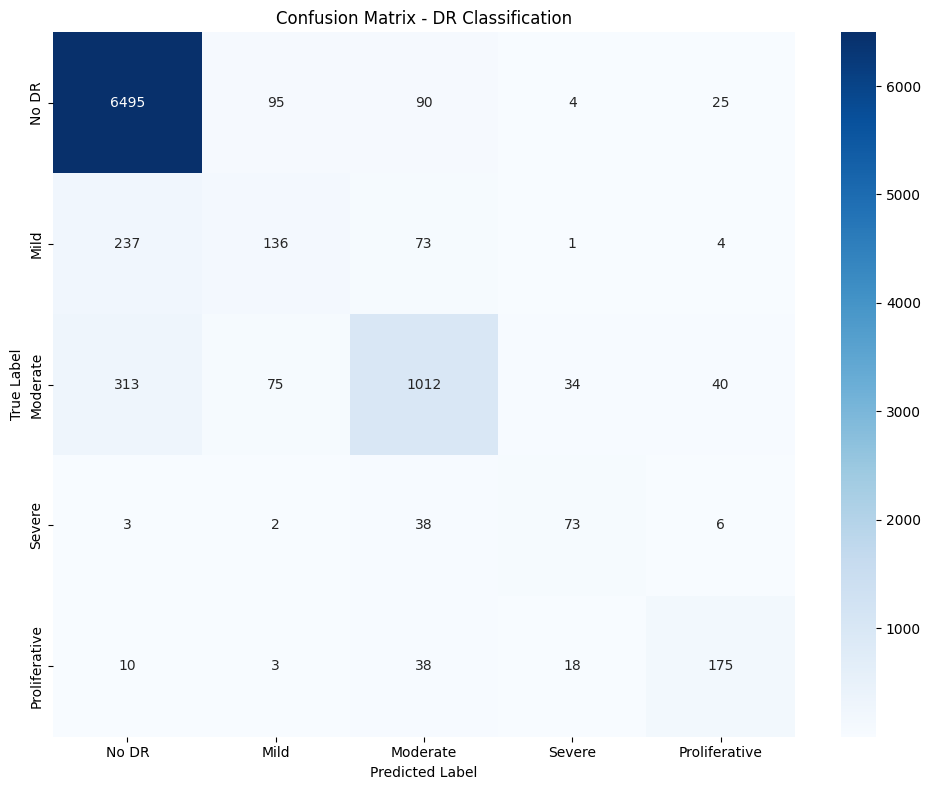


Classification Report:
               precision    recall  f1-score   support

        No DR     0.9202    0.9681    0.9436      6709
         Mild     0.4373    0.3016    0.3570       451
     Moderate     0.8090    0.6866    0.7428      1474
       Severe     0.5615    0.5984    0.5794       122
Proliferative     0.7000    0.7172    0.7085       244

     accuracy                         0.8768      9000
    macro avg     0.6856    0.6544    0.6662      9000
 weighted avg     0.8670    0.8768    0.8700      9000



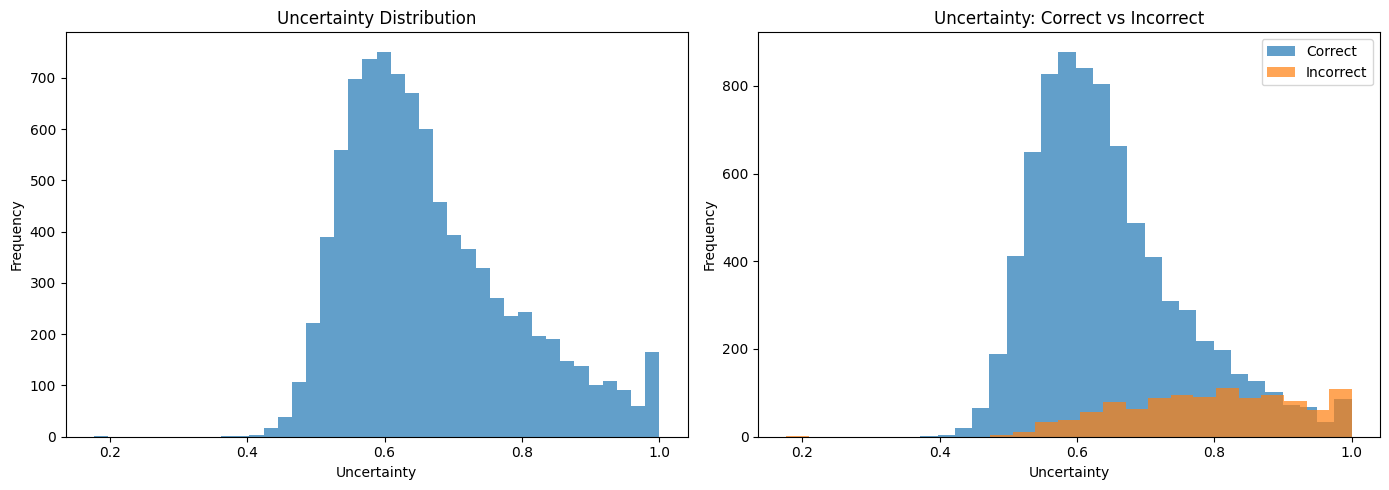


✓ Evaluation complete at 2026-03-16 08:15:04



In [12]:
import os
import re
import glob
from datetime import datetime
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("=" * 80)
print("MODEL EVALUATION AND TESTING")
print("=" * 80)
print("NOTE: This cell is manual. If training was interrupted (e.g., during plot_training_history), run this cell explicitly.")
print(f"Evaluation run started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']
class_ids = [0, 1, 2, 3, 4]


def parse_f1_from_filename(path):
    """Parse F1 from checkpoint filename like checkpoint_epoch_50_f1_0.5703.pt."""
    m = re.search(r"_f1_([0-9]*\.?[0-9]+)\.pt$", os.path.basename(path))
    return float(m.group(1)) if m else -1.0


def choose_best_checkpoint(checkpoint_dir):
    """Choose checkpoint with highest available validation macro-F1."""
    best_model_path = os.path.join(checkpoint_dir, 'best_model.pt')
    named_ckpts = glob.glob(os.path.join(checkpoint_dir, 'checkpoint_epoch_*_f1_*.pt'))

    candidate_paths = []
    if os.path.exists(best_model_path):
        candidate_paths.append(best_model_path)
    candidate_paths.extend(named_ckpts)

    if not candidate_paths:
        raise FileNotFoundError(f"No checkpoint files found in {checkpoint_dir}")

    best_path = None
    best_score = -1.0

    print("\nCheckpoint candidates:")
    for path in candidate_paths:
        score = parse_f1_from_filename(path)
        src = 'filename'

        # Try metadata score when available (more reliable than filename)
        try:
            ckpt = torch.load(path, map_location='cpu', weights_only=False)
            if 'val_metrics' in ckpt and isinstance(ckpt['val_metrics'], dict) and 'macro_f1' in ckpt['val_metrics']:
                score = float(ckpt['val_metrics']['macro_f1'])
                src = 'metadata'
        except Exception:
            pass

        print(f"  - {os.path.basename(path)} -> macro_f1={score:.4f} ({src})")

        if score > best_score:
            best_score = score
            best_path = path

    return best_path, best_score


# Verify prerequisites
if 'EfficientNetB3EDL' not in locals():
    print("⚠ Model class not loaded. Run 'Load Model Definition and Classes for Evaluation' first")
elif 'test_loader' not in locals():
    print("⚠ test_loader not found. Run 'Create Test DataLoader for Evaluation' first")
else:
    try:
        if 'EVAL_TEST_SPLIT_SIZE' in globals() and 'EVAL_VALID_TEST_SIZE' in globals():
            print(f"\n✓ Evaluation split metadata: target_test={EVAL_TEST_SPLIT_SIZE}, valid_test={EVAL_VALID_TEST_SIZE}")
        else:
            print("\n⚠ Split metadata not found. Re-run the previous DataLoader cell to ensure correct test split.")

        checkpoint_dir = '/content/drive/MyDrive/EyeShield/checkpoints'
        checkpoint_path, selected_score = choose_best_checkpoint(checkpoint_dir)

        print("\n✓ Loading selected checkpoint...")
        checkpoint = torch.load(checkpoint_path, weights_only=False)

        model = EfficientNetB3EDL(num_classes=5, pretrained=False)
        model.load_state_dict(checkpoint['model_state'])
        model.to(device)
        model.eval()

        print("✓ Model loaded successfully")
        print(f"  - Checkpoint path: {checkpoint_path}")
        print(f"  - Selected macro F1 score: {selected_score:.4f}")
        print(f"  - Checkpoint epoch: {checkpoint.get('epoch', 'unknown')}")
        print(f"  - Model parameters: {sum(p.numel() for p in model.parameters()):,}")
        if 'val_metrics' in checkpoint and isinstance(checkpoint['val_metrics'], dict):
            vm = checkpoint['val_metrics']
            if 'macro_f1' in vm:
                print(f"  - Checkpoint val macro F1: {vm['macro_f1']:.4f}")
            if 'accuracy' in vm:
                print(f"  - Checkpoint val accuracy: {vm['accuracy']:.4f}")

        print("\nRunning evaluation on test set...")
        all_preds = []
        all_targets = []
        all_uncertainties = []

        with torch.no_grad():
            for images, targets in test_loader:
                images = images.to(device, non_blocking=True)
                targets = targets.to(device, non_blocking=True)

                evidence = model(images)
                output = model.predict(evidence)

                all_preds.extend(output['pred'].cpu().numpy().tolist())
                all_targets.extend(targets.cpu().numpy().tolist())
                all_uncertainties.extend(output['uncertainty'].cpu().numpy().reshape(-1).tolist())

        all_preds = np.array(all_preds, dtype=np.int64)
        all_targets = np.array(all_targets, dtype=np.int64)
        all_uncertainties = np.array(all_uncertainties, dtype=np.float32)

        print(f"✓ Evaluated samples: {len(all_targets)}")

        # Distribution diagnostics
        true_counts = np.bincount(all_targets, minlength=5)
        pred_counts = np.bincount(all_preds, minlength=5)

        print("\nClass distribution (true vs predicted):")
        for cid, cname in enumerate(class_names):
            print(f"  {cname:<13} true={true_counts[cid]:5d}  pred={pred_counts[cid]:5d}")

        unique_pred = np.unique(all_preds)
        if len(unique_pred) == 1:
            print(f"\n⚠ Prediction collapse detected: model predicted only class {int(unique_pred[0])} ({class_names[int(unique_pred[0])]})")
            print("  This usually indicates dataset/path/preprocessing mismatch during evaluation.")

        # Confusion matrix with fixed class axes
        cm = confusion_matrix(all_targets, all_preds, labels=class_ids)

        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=ax,
            xticklabels=class_names,
            yticklabels=class_names,
        )
        ax.set_title('Confusion Matrix - DR Classification')
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')
        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/EyeShield/logs/confusion_matrix.png', dpi=300)
        plt.show()

        # Classification report with fixed labels
        print("\nClassification Report:")
        print(
            classification_report(
                all_targets,
                all_preds,
                labels=class_ids,
                target_names=class_names,
                digits=4,
                zero_division=0,
            )
        )

        # Uncertainty plots (downsample if very large to keep plotting responsive)
        max_points = 20000
        if len(all_uncertainties) > max_points:
            rng = np.random.default_rng(42)
            idx = rng.choice(len(all_uncertainties), size=max_points, replace=False)
            unc_plot = all_uncertainties[idx]
            preds_plot = all_preds[idx]
            targets_plot = all_targets[idx]
            print(f"\n⚠ Downsampled uncertainty plots to {max_points} points for responsiveness")
        else:
            unc_plot = all_uncertainties
            preds_plot = all_preds
            targets_plot = all_targets

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].hist(unc_plot, bins=40, alpha=0.7)
        axes[0].set_title('Uncertainty Distribution')
        axes[0].set_xlabel('Uncertainty')
        axes[0].set_ylabel('Frequency')

        correct_mask = preds_plot == targets_plot
        correct_unc = unc_plot[correct_mask]
        incorrect_unc = unc_plot[~correct_mask]

        axes[1].hist(correct_unc, bins=25, alpha=0.7, label='Correct')
        axes[1].hist(incorrect_unc, bins=25, alpha=0.7, label='Incorrect')
        axes[1].set_title('Uncertainty: Correct vs Incorrect')
        axes[1].set_xlabel('Uncertainty')
        axes[1].set_ylabel('Frequency')
        axes[1].legend()

        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/EyeShield/logs/uncertainty_analysis.png', dpi=300)
        plt.show()

        EVALUATION_LAST_RUN_AT = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        print(f"\n✓ Evaluation complete at {EVALUATION_LAST_RUN_AT}")

    except FileNotFoundError as e:
        print(f"❌ File not found: {e}")
        print('   Make sure checkpoints have been saved during training')
    except Exception as e:
        print(f"❌ Error: {type(e).__name__}: {str(e)}")
        import traceback
        traceback.print_exc()

print("\n" + "=" * 80)